# Studi Kasus 2: Sifat Termodinamika Model Ising 2D pada Transisi Fasa & Kritikalitas ($T = 2.27$)

## 1. Konteks Fisis
Dalam mekanika statistik, ketika material feromagnetik dipanaskan mendekati temperatur kritis Onsager ($T_c \approx 2.27$), sistem mengalami transisi fase termodinamika kontinu (orde kedua). Pada suhu kritis $T = 2.27$, sistem berada tepat pada batas antara fase feromagnetik yang sangat teratur dan fase paramagnetik yang acak sempurna. Pada titik kritikalitas ini, energi kopling antar-spin ($J$) dan fluktuasi termal ($k_B T$) saling berkompetisi dengan kekuatan yang seimbang.

Mekanisme fisis utama yang mendominasi sistem adalah munculnya **fluktuasi kritis (critical fluctuations)** pada semua skala panjang secara bersamaan. Ketika simulasi berjalan dari konfigurasi awal acak (**Hot Start**), spin-spin tidak melebur menjadi satu domain tunggal raksasa (seperti pada $T = 1.0$), melainkan mengatur dirinya membentuk struktur kluster-kluster geometris berpola **fraktal self-similar** (memiliki kemiripan bentuk saat diperbesar). Fenomena ini menandai **runtuhnya keteraturan jarak jauh (long-range order)**, di mana orientasi makroskopis sistem menjadi sangat sensitif terhadap gangguan kecil sekalipun.

## 2. Ekspektasi Matematis
Berdasarkan perumusan Hamiltonian Ising tanpa medan magnet luar:
$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$

Perubahan energi lokal ($\Delta E$) yang dihitung saat sebuah spin dicoba untuk dibalik pada kisi persegi dinyatakan sebagai:
$$\Delta E = 2 s_i \sum_{j \in \text{neighbors}} s_j$$

Berdasarkan **Kriteria Metropolis**, probabilitas penerimaan transisi yang menaikkan energi sistem ($\Delta E > 0$) dikontrol oleh faktor Boltzmann pada suhu kritis:
$$\mathcal{R} = e^{-\frac{\Delta E}{T_c}} = e^{-\frac{\Delta E}{2.27}}$$

Karena sistem berada pada titik kritis, probabilitas $\mathcal{R}$ bernilai moderat. Hal ini memungkinkan fluktuasi termal membalikkan kelompok-kelompok spin secara dinamis, mencegah sistem mengalami saturasi magnetik makroskopis. Akibatnya, alih-alih konvergen mantap menuju nilai $\pm 1$, kurva nilai mutlak magnetisasi rata-rata per spin ($|M|$) akan mengalami fluktuasi yang sangat liar dan tajam di sepanjang rentang nilai menengah:
$$|M| = \left| \frac{1}{N^2} \sum_{i=1}^{N^2} s_i \right| \in (0, 1)$$

Varians dari magnetisasi ini akan meningkat secara drastis, merepresentasikan divergensi teoritis dari kerentanan magnetik ($\chi \propto \text{Var}(M)$) serta fenomena perlambatan kritis (*critical slowing down*).
---

## 3. Implementasi Komputasi


    

Menjalankan simulasi untuk Case 2 (T = 2.27). Silakan tunggu...


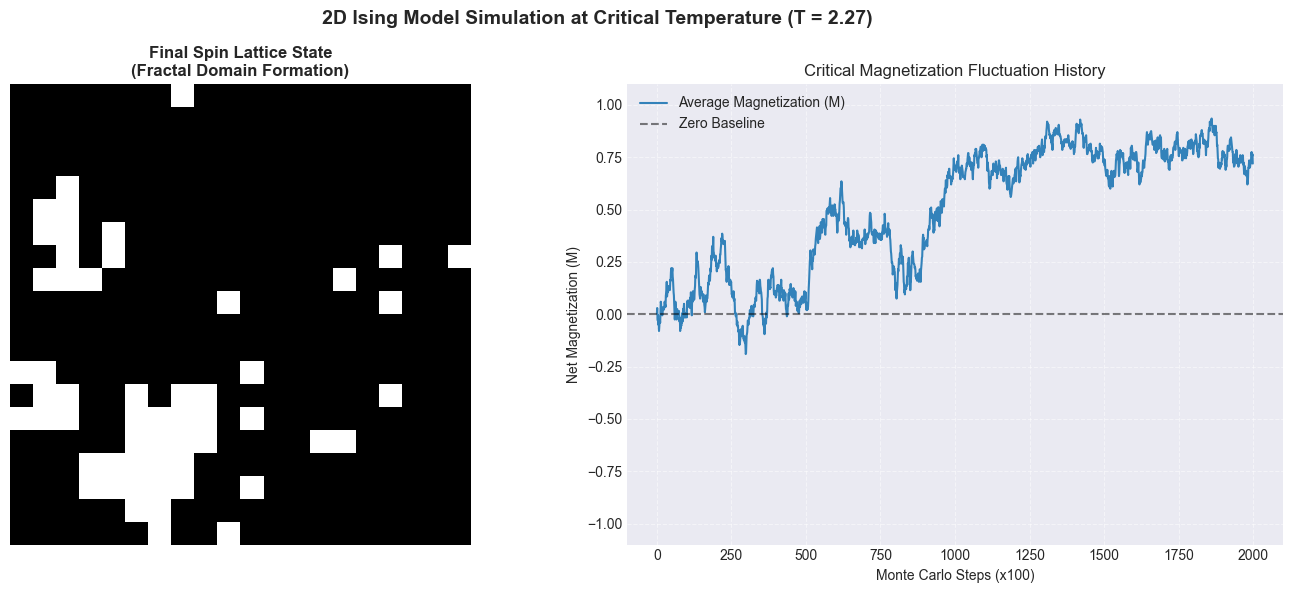

Simulasi Case 2 selesai dieksekusi!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Mengaktifkan gaya plot akademis yang bersih
plt.style.use('seaborn-v0_8-darkgrid')

def metropolis_step(grid, T):
    """Melakukan satu langkah percobaan pembalikan spin menggunakan algoritma Metropolis."""
    N = grid.shape[0]
    # Memilih koordinat spin acak
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    
    # Menghitung jumlah 4 spin tetangga terdekat dengan Kondisi Batas Periodik (%)
    s_neighbors = (
        grid[(x+1)%N, y] +
        grid[(x-1)%N, y] +
        grid[x, (y+1)%N] +
        grid[x, (y-1)%N]
    )
    
    # Menghitung perubahan energi lokal delta_E = 2 * s_i * sum(s_j)
    delta_E = 2 * grid[x, y] * s_neighbors
    
    # Evaluasi Kriteria Metropolis
    if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1  # Terima pembalikan spin
        
    return grid

def run_simulation(N=20, temp=2.27, n_steps=200000):
    """Menjalankan loop Monte Carlo penuh dimulai dari Hot Start pada suhu kritis."""
    # Inisialisasi Hot Start (Konfigurasi acak acak antara -1 dan 1)
    grid = np.random.choice([-1, 1], size=(N, N))
    magnetization_history = []
    
    for step in range(n_steps):
        grid = metropolis_step(grid, temp)
        
        # Ambil sampel data magnetisasi setiap 100 langkah demi efisiensi
        if step % 100 == 0:
            magnetization = np.mean(grid)
            magnetization_history.append(magnetization)
            
    return grid, magnetization_history

# --- Parameter Eksperimen Kasus 2 ---
GRID_SIZE = 20
MONTE_CARLO_STEPS = 200000
T_CASE = 2.27

print(f"Menjalankan simulasi untuk Case 2 (T = {T_CASE}). Silakan tunggu...")
final_grid, M_history = run_simulation(N=GRID_SIZE, temp=T_CASE, n_steps=MONTE_CARLO_STEPS)

# --- Visualisasi Hasil Subplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"2D Ising Model Simulation at Critical Temperature (T = {T_CASE})", fontsize=14, fontweight='bold')

# Subplot 1: Konfigurasi Kisi Akhir Spin
axes[0].imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title("Final Spin Lattice State\n(Fractal Domain Formation)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Subplot 2: Riwayat Magnetisasi Rata-rata
axes[1].plot(M_history, color='tab:blue', alpha=0.9, linewidth=1.5, label='Average Magnetization (M)')
axes[1].axhline(0.0, color='black', linestyle='--', alpha=0.5, label='Zero Baseline')
axes[1].set_title("Critical Magnetization Fluctuation History", fontsize=12)
axes[1].set_xlabel("Monte Carlo Steps (x100)")
axes[1].set_ylabel("Net Magnetization (M)")
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("Simulasi Case 2 selesai dieksekusi!")

## 4. Diskusi & Interpretasi Fisis

Berdasarkan grafik dan visualisasi yang dihasilkan dari simulasi Model Ising 2D pada suhu kritis ($T = 2.27$), kita dapat mengevaluasi beberapa perilaku fisis sebagai berikut:

* **Analisis Spasial Konfigurasi Kisi:** Gambar matriks keadaan akhir grid menunjukkan pulau-pulau hitam dan putih yang saling menembus, membentuk struktur batas wilayah yang sangat kompleks dan kasar. Keadaan ini merepresentasikan pembentukan **pola domain fraktal**, di mana tidak ada satu warna tunggal yang mendominasi seluruh kisi secara permanen. Pola pulau-pulau bercabang ini menjadi bukti fisik hilangnya keteraturan jarak jauh (*long-range order*) yang digantikan oleh keteraturan jarak pendek yang dinamis, menunjukkan sifat *self-similarity* dari transisi fase orde kedua.
* **Analisis Riwayat Magnetisasi:** Kurva pelacakan magnetisasi menunjukkan perilaku yang sangat berbeda dari Kasus 1. Grafik tidak mengalami konvergensi stabil menuju nilai mutlak $|M| \approx 1$, melainkan memperlihatkan **fluktuasi kritis** berupa ayunan naik-turun yang sangat tajam, lebar, dan tidak beraturan di sepanjang waktu simulasi. Varians kurva yang sangat besar ini mengonfirmasi secara empiris terjadinya lonjakan kerentanan magnetik ($\chi$) sistem, yang dipicu oleh fenomena *critical slowing down*, di mana waktu relaksasi yang dibutuhkan sistem untuk mencapai kesetimbangan termal meningkat secara signifikan akibat hilangnya gaya pemulih termodinamika tunggal di titik kritis.